# Proposed Model Enhancements



In [2]:
# STEP 1: Core imports
import random
import time
import numpy as np
import torch
import pandas as pd
from transformers import set_seed

# GPU: enable TF32 on Ampere GPUs (A100, RTX 30xx) for extra speed at no accuracy cost
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [3]:
# STEP 2: Reproducibility — full seed lock
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

# Deterministic ops on GPU (slight speed trade-off for full reproducibility)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"All seeds fixed to {SEED}")
print("cuDNN deterministic: True (reproducible across runs)")

All seeds fixed to 42
cuDNN deterministic: True (reproducible across runs)


In [4]:
# STEP 3: GPU enforcement + CUDA warm-up
# Raises an error immediately if no GPU is found so you don't waste time
# ── Google Colab: Runtime > Change runtime type > T4 GPU
# ── Local:        install torch+cuda from https://pytorch.org/get-started/locally/
import time

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU detected.\n"
        "On Google Colab: Runtime > Change runtime type > Hardware accelerator > GPU (T4)\n"
        "On local machine: install torch with CUDA — https://pytorch.org/get-started/locally/"
    )

DEVICE = torch.device("cuda")

print("="*55)
print("GPU Information")
print("="*55)
print(f"GPU name:       {torch.cuda.get_device_name(0)}")
print(f"CUDA version:   {torch.version.cuda}")
print(f"cuDNN version:  {torch.backends.cudnn.version()}")
print(f"Total VRAM:     {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Torch version:  {torch.__version__}")
print()

# Warm up CUDA context — avoids cold-start penalty during first training step
_ = torch.zeros(1).to(DEVICE)
print("CUDA context warmed up. Ready.")

GPU Information
GPU name:       NVIDIA GeForce RTX 4060
CUDA version:   12.1
cuDNN version:  90100
Total VRAM:     8.6 GB
Torch version:  2.5.1+cu121

CUDA context warmed up. Ready.


In [5]:
# Create results directory for all outputs
import os
os.makedirs("./results", exist_ok=True)
print("Results directory ready: ./results/")

Results directory ready: ./results/


In [6]:
# STEP 4: Load dataset
df = pd.read_csv("deceptive-opinion.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1600, 5)


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...
3,truthful,omni,positive,TripAdvisor,The Omni Chicago really delivers on all fronts...
4,truthful,hyatt,positive,TripAdvisor,I asked for a high floor away from the elevato...


In [7]:
# STEP 5: Data cleaning
df = df[["text", "deceptive"]]

df = df.rename(columns={
    "text": "review",
    "deceptive": "label"
})

df["label"] = df["label"].map({
    "truthful": 0,
    "deceptive": 1
})

df["review"] = df["review"].astype(str).str.strip()
df["review"] = df["review"].str.replace(r"\s+", " ", regex=True)

df = df.dropna().drop_duplicates()

print(df.info())
print()
print(df["label"].value_counts())

<class 'pandas.DataFrame'>
Index: 1596 entries, 0 to 1599
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1596 non-null   str  
 1   label   1596 non-null   int64
dtypes: int64(1), str(1)
memory usage: 1.3 MB
None

label
1    800
0    796
Name: count, dtype: int64


In [8]:
# STEP 6: IMPROVED — Check token length distribution before choosing max_length
# This ensures we're not silently truncating reviews and biasing the dataset
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

sample_lengths = [len(tokenizer.encode(t)) for t in df["review"]]
p95 = sorted(sample_lengths)[int(0.95 * len(sample_lengths))]
p99 = sorted(sample_lengths)[int(0.99 * len(sample_lengths))]

print(f"Token length stats:")
print(f"  Min:    {min(sample_lengths)}")
print(f"  Max:    {max(sample_lengths)}")
print(f"  Mean:   {np.mean(sample_lengths):.1f}")
print(f"  95th %: {p95}   <-- set max_length above this")
print(f"  99th %: {p99}")

# Set max_length based on the actual distribution
MAX_LENGTH = max(128, min(512, p99 + 16))
print(f"\nUsing max_length = {MAX_LENGTH}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (531 > 512). Running this sequence through the model will result in indexing errors


Token length stats:
  Min:    30
  Max:    930
  Mean:   177.7
  95th %: 381   <-- set max_length above this
  99th %: 531

Using max_length = 512


In [9]:
# STEP 7: Train / validation / test split  (70 / 15 / 15)
from sklearn.model_selection import train_test_split

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["review"],
    df["label"],
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print(f"Train:      {len(train_texts)} samples")
print(f"Validation: {len(val_texts)} samples")
print(f"Test:       {len(test_texts)} samples")

Train:      1117 samples
Validation: 239 samples
Test:       240 samples


In [10]:
# STEP 8: Tokenization  (uses MAX_LENGTH derived from data above)
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=MAX_LENGTH)
val_encodings   = tokenizer(list(val_texts),   truncation=True, padding=True, max_length=MAX_LENGTH)
test_encodings  = tokenizer(list(test_texts),  truncation=True, padding=True, max_length=MAX_LENGTH)

print("Tokenization complete.")

Tokenization complete.


In [11]:
# STEP 9: PyTorch Dataset
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
val_dataset   = ReviewDataset(val_encodings,   val_labels)
test_dataset  = ReviewDataset(test_encodings,  test_labels)

print(f"Datasets ready: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Datasets ready: train=1117, val=239, test=240


In [12]:
# STEP 10: Compute class weights for balanced loss
from sklearn.utils.class_weight import compute_class_weight

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=list(train_labels)
)

class_weights = torch.tensor(class_weights_np, dtype=torch.float)
print(f"Class weights: {class_weights}")
print(f"  (class 0=Genuine: {class_weights[0]:.4f}, class 1=Deceptive: {class_weights[1]:.4f})")

Class weights: tensor([1.0027, 0.9973])
  (class 0=Genuine: 1.0027, class 1=Deceptive: 0.9973)


In [13]:
# STEP 11: Load RoBERTa with explicit dropout config
from transformers import RobertaForSequenceClassification, RobertaConfig

config = RobertaConfig.from_pretrained(
    "roberta-base",
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    classifier_dropout=0.1
)

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    ignore_mismatched_sizes=True
)

# Move model to GPU explicitly
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model loaded: roberta-base + classification head")
print(f"Device:           {next(model.parameters()).device}")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print()
vram_used = torch.cuda.memory_allocated(0) / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM used by model: {vram_used:.2f} GB / {vram_total:.1f} GB")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5045.29it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: roberta-base + classification head
Device:           cuda:0
Total params:     124,647,170
Trainable params: 124,647,170

VRAM used by model: 0.50 GB / 8.6 GB


In [14]:
# STEP 12: Evaluation metrics — precision, recall, F1, accuracy
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds  = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy":  acc,
        "precision": precision,
        "recall":    recall,
        "f1":        f1
    }

In [15]:
# STEP 13: IMPROVED — WeightedTrainer with class_weights passed explicitly
# Avoids the closure dependency bug (stale weights if cells run out of order)
from transformers import Trainer
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")

        loss_fct = CrossEntropyLoss(
            weight=self.class_weights.to(model.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss

In [16]:
# STEP 14: IMPROVED — Metrics logger callback for clean per-epoch history
# Replaces fragile trainer.state.log_history parsing for plots
from transformers import TrainerCallback

class MetricsLogger(TrainerCallback):
    def __init__(self):
        self.history = []

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics:
            self.history.append({k: v for k, v in metrics.items()})

metrics_logger = MetricsLogger()
print("MetricsLogger ready.")

MetricsLogger ready.


In [17]:
# STEP 15: Training arguments
# GPU optimisations already included:
#   fp16=True                   — mixed precision, ~40% faster on T4/A100
#   gradient_accumulation_steps — effective batch=32, better gradient estimates
#   cosine LR + warmup          — smooth training, avoids early loss spikes
from transformers import TrainingArguments, EarlyStoppingCallback

USE_FP16 = torch.cuda.is_available()  # auto-detect: True on GPU, False on CPU

training_args = TrainingArguments(
    output_dir="./proposed_results",

    # Evaluation & saving
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Optimisation
    learning_rate=1e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,        # effective batch = 32
    num_train_epochs=10,                   # early stopping cuts this short
    weight_decay=0.01,

    # GPU speed
    fp16=USE_FP16,                         # mixed precision on GPU

    # Logging
    logging_strategy="epoch",
    report_to="none",

    # Reproducibility
    seed=SEED,
    data_seed=SEED,
)

early_stopping = EarlyStoppingCallback(early_stopping_patience=3)

# ── Pre-flight check ───────────────────────────────────────────────────────
print("="*55)
print("Training Configuration")
print("="*55)
print(f"Device:               {DEVICE}")
print(f"fp16 (mixed prec):    {USE_FP16}")
print(f"Learning rate:        {training_args.learning_rate}")
print(f"Epochs (max):         {int(training_args.num_train_epochs)}")
print(f"Batch per device:     {training_args.per_device_train_batch_size}")
print(f"Grad accum steps:     {training_args.gradient_accumulation_steps}")
print(f"Effective batch:      {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"LR scheduler:         {training_args.lr_scheduler_type}")
print(f"Warmup ratio:         {training_args.warmup_ratio}")
print(f"Early stop patience:  3 epochs on F1")
print()

# ── Estimate training time ─────────────────────────────────────────────────
model.eval()
sample = {k: torch.tensor(v[:training_args.per_device_train_batch_size]).to(DEVICE)
          for k, v in train_encodings.items()}
t0 = time.time()
with torch.no_grad():
    _ = model(**sample)
torch.cuda.synchronize()
fwd_time = time.time() - t0

steps_per_epoch = len(train_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)
total_steps     = steps_per_epoch * int(training_args.num_train_epochs)
est_sec         = fwd_time * total_steps * 3   # fwd+bwd+optim ≈ 3x fwd

print(f"Steps per epoch:      {steps_per_epoch}")
print(f"Max total steps:      {total_steps}  (early stopping likely cuts this)")
print(f"Estimated max time:   {est_sec/60:.1f} min  (early stopping likely ~{est_sec/60*0.4:.0f}–{est_sec/60*0.6:.0f} min)")
print()
vram_used = torch.cuda.memory_allocated(0) / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM before training: {vram_used:.2f} GB / {vram_total:.1f} GB")
model.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Configuration
Device:               cuda
fp16 (mixed prec):    True
Learning rate:        1e-05
Epochs (max):         10
Batch per device:     16
Grad accum steps:     2
Effective batch:      32
LR scheduler:         SchedulerType.COSINE
Warmup ratio:         0.1
Early stop patience:  3 epochs on F1

Steps per epoch:      34
Max total steps:      340  (early stopping likely cuts this)
Estimated max time:   15.8 min  (early stopping likely ~6–9 min)

VRAM before training: 0.51 GB / 8.6 GB


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [18]:
# STEP 16: Train proposed model
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[early_stopping, metrics_logger]
)

# Reset VRAM peak stats so we measure training only
torch.cuda.reset_peak_memory_stats(0)
t_start = time.time()

trainer.train()

t_elapsed = time.time() - t_start
peak_vram = torch.cuda.max_memory_allocated(0) / 1e9

print()
print("="*45)
print("Training complete")
print("="*45)
print(f"Wall time:        {t_elapsed/60:.1f} min ({t_elapsed:.0f} s)")
print(f"Peak VRAM used:   {peak_vram:.2f} GB")
epochs_run = len(metrics_logger.history)
print(f"Epochs completed: {epochs_run}  (early stopping at best F1 checkpoint)")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.405071,0.687819,0.497908,0.000000,0.000000,0.000000
2,1.203745,0.368407,0.870293,0.834586,0.925000,0.877470
3,0.636539,0.336628,0.878661,0.837037,0.941667,0.886275
4,0.478871,0.258641,0.903766,0.929204,0.875000,0.901288
5,0.334494,0.326479,0.887029,0.839416,0.958333,0.894942
6,0.187694,0.325619,0.903766,0.875969,0.941667,0.907631
7,0.171254,0.339149,0.907950,0.901639,0.916667,0.909091
8,0.103123,0.393505,0.903766,0.864662,0.958333,0.909091
9,0.066943,0.391208,0.912134,0.877863,0.958333,0.916335
10,0.054653,0.375479,0.920502,0.891473,0.958333,0.923695


c:\ML_in_Cyber\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.50it/s]



Training complete
Wall time:        4.2 min (252 s)
Peak VRAM used:   5.68 GB
Epochs completed: 10  (early stopping at best F1 checkpoint)


In [19]:
# Proposed RoBERTa — Test Set Metrics Summary
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import json, os

preds  = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

acc               = accuracy_score(y_true, y_pred)
prec, rec, f1, _  = precision_recall_fscore_support(y_true, y_pred, average="binary")
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1])

print("=" * 55)
print(f"Proposed RoBERTa")
print("Test Set Metrics Summary")
print("=" * 55)
print(f"  Metric                Score")
print(f"  {'-'*28}")
print(f"  {'Accuracy':<18} {acc:>8.4f}")
print(f"  {'Precision':<18} {prec:>8.4f}")
print(f"  {'Recall':<18} {rec:>8.4f}")
print(f"  {'F1-Score':<18} {f1:>8.4f}")
print()
print(f"  Per-class breakdown:")
print(f"  {'Class':<18} {'Precision':>9} {'Recall':>8} {'F1':>8} {'Support':>8}")
print(f"  {'-'*56}")
for cls_idx, cls_name in enumerate(['Genuine (0)', 'Deceptive (1)']):
    print(f"  {cls_name:<18} {prec_c[cls_idx]:>9.4f} {rec_c[cls_idx]:>8.4f} {f1_c[cls_idx]:>8.4f} {int(sup_c[cls_idx]):>8}")
print()


# Save results to JSON for later comparison notebook
os.makedirs("./results", exist_ok=True)
results_dict = {
    "model":     "proposed",
    "accuracy":  round(float(acc),  4),
    "precision": round(float(prec), 4),
    "recall":    round(float(rec),  4),
    "f1":        round(float(f1),   4),
    "per_class": {
        "genuine":   {"precision": round(float(prec_c[0]),4), "recall": round(float(rec_c[0]),4), "f1": round(float(f1_c[0]),4), "support": int(sup_c[0])},
        "deceptive": {"precision": round(float(prec_c[1]),4), "recall": round(float(rec_c[1]),4), "f1": round(float(f1_c[1]),4), "support": int(sup_c[1])}
    }
}
with open(f"./results/proposed_metrics.json", "w") as f:
    json.dump(results_dict, f, indent=2)
print(f"  Metrics saved → ./results/proposed_metrics.json")

Proposed RoBERTa
Test Set Metrics Summary
  Metric                Score
  ----------------------------
  Accuracy             0.8958
  Precision            0.8519
  Recall               0.9583
  F1-Score             0.9020

  Per-class breakdown:
  Class              Precision   Recall       F1  Support
  --------------------------------------------------------
  Genuine (0)           0.9524   0.8333   0.8889      120
  Deceptive (1)         0.8519   0.9583   0.9020      120

  Metrics saved → ./results/proposed_metrics.json


In [20]:
# Proposed RoBERTa — Classification Report
from sklearn.metrics import classification_report, confusion_matrix

print("=" * 55)
print(f"Proposed RoBERTa")
print("Classification Report")
print("=" * 55)
print(classification_report(
    y_true, y_pred,
    target_names=["Genuine (0)", "Deceptive (1)"],
    digits=4
))
print("Confusion Matrix (raw):")
cm = confusion_matrix(y_true, y_pred)
print(f"  TN={cm[0,0]}  FP={cm[0,1]}")
print(f"  FN={cm[1,0]}  TP={cm[1,1]}")

Proposed RoBERTa
Classification Report
               precision    recall  f1-score   support

  Genuine (0)     0.9524    0.8333    0.8889       120
Deceptive (1)     0.8519    0.9583    0.9020       120

     accuracy                         0.8958       240
    macro avg     0.9021    0.8958    0.8954       240
 weighted avg     0.9021    0.8958    0.8954       240

Confusion Matrix (raw):
  TN=100  FP=20
  FN=5  TP=115


C:\Users\My PC\AppData\Local\Temp\ipykernel_34996\2767893482.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


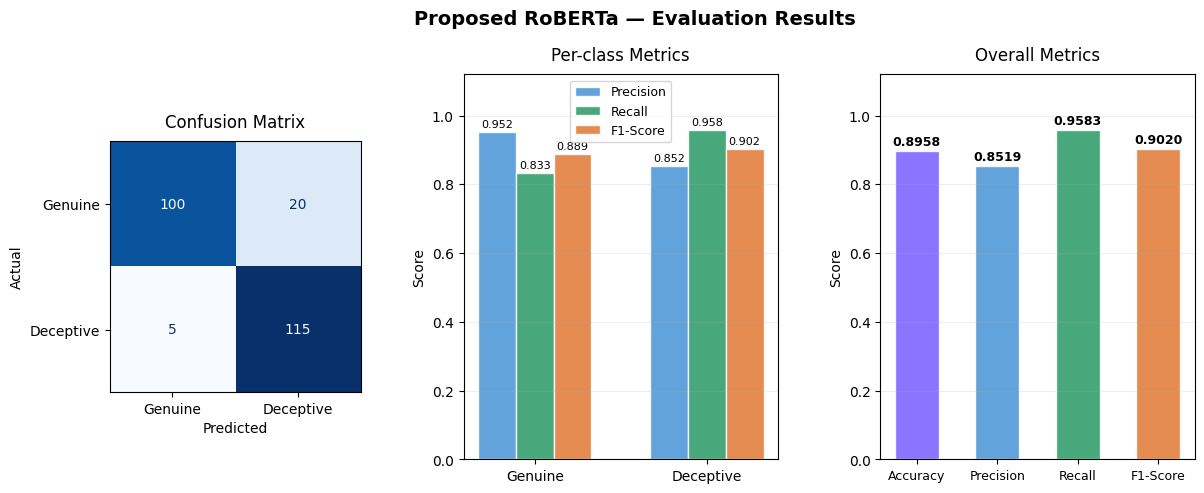

Saved → ./results/proposed_evaluation.png


In [21]:
# Proposed RoBERTa — Confusion Matrix & Per-class Metrics
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 5))
fig.suptitle("Proposed RoBERTa — Evaluation Results", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1.2, 1.5, 1.5], wspace=0.35)

# ── Panel 1: Confusion matrix ─────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=["Genuine", "Deceptive"],
    cmap="Blues", colorbar=False, ax=ax0
)
ax0.set_title("Confusion Matrix", fontsize=12, pad=10)
ax0.set_xlabel("Predicted", fontsize=10)
ax0.set_ylabel("Actual",    fontsize=10)

# ── Panel 2: Per-class grouped bar ───────────────────────────────────────
prec_c, rec_c, f1_c, sup_c = precision_recall_fscore_support(y_true, y_pred, labels=[0,1])
classes = ["Genuine", "Deceptive"]
x, w    = np.arange(len(classes)), 0.22

ax1 = fig.add_subplot(gs[1])
b1 = ax1.bar(x - w,   prec_c, w, label="Precision", color="#4C96D7", alpha=0.88, edgecolor="white")
b2 = ax1.bar(x,       rec_c,  w, label="Recall",    color="#2E9C6A", alpha=0.88, edgecolor="white")
b3 = ax1.bar(x + w,   f1_c,   w, label="F1-Score",  color="#E07B39", alpha=0.88, edgecolor="white")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.008,
                 f"{h:.3f}", ha="center", va="bottom", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(classes, fontsize=10)
ax1.set_ylim(0, 1.12); ax1.set_ylabel("Score", fontsize=10)
ax1.set_title("Per-class Metrics", fontsize=12, pad=10)
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2, axis="y")

# ── Panel 3: Aggregate metric bar ────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_recall_fscore_support as prf
acc_v               = accuracy_score(y_true, y_pred)
prec_v, rec_v, f1_v, _ = prf(y_true, y_pred, average="binary")
metric_names  = ["Accuracy", "Precision", "Recall", "F1-Score"]
metric_values = [acc_v, prec_v, rec_v, f1_v]
bar_colors    = ["#7B61FF", "#4C96D7", "#2E9C6A", "#E07B39"]

ax2 = fig.add_subplot(gs[2])
bars = ax2.bar(metric_names, metric_values, color=bar_colors, alpha=0.88, edgecolor="white", width=0.55)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylim(0, 1.12); ax2.set_ylabel("Score", fontsize=10)
ax2.set_title("Overall Metrics", fontsize=12, pad=10)
ax2.tick_params(axis="x", labelsize=9); ax2.grid(True, alpha=0.2, axis="y")

plt.tight_layout()
plt.savefig("./results/proposed_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ./results/proposed_evaluation.png")

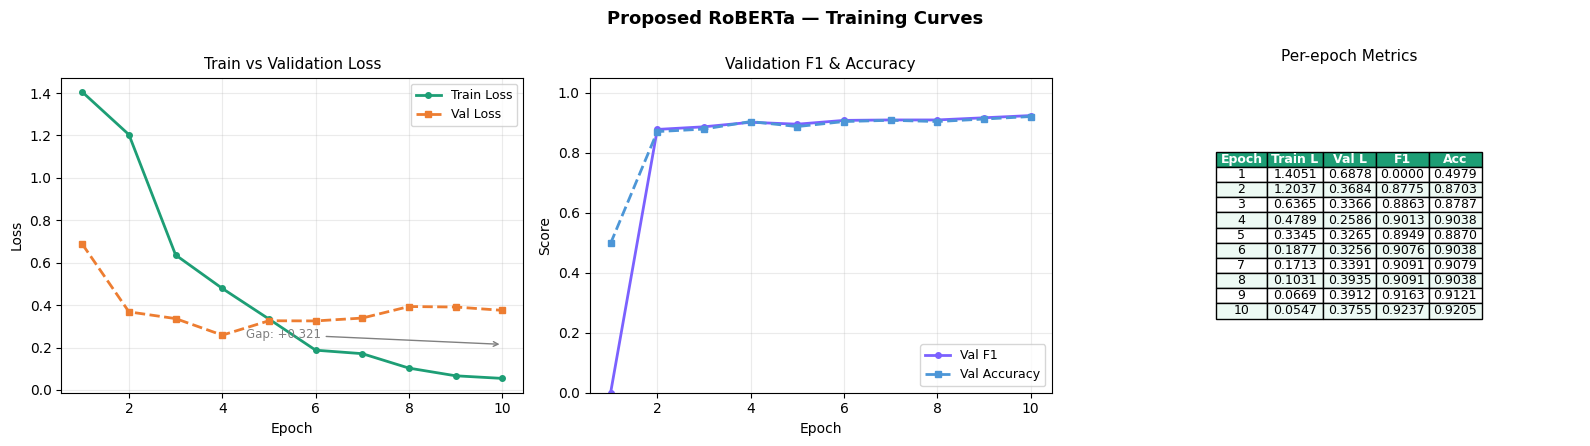

Saved → ./results/proposed_loss_curves.png

Final train loss: 0.0547
Final val loss:   0.3755
Final gap:        +0.3208
Best val F1:      0.9237  (epoch 10)


In [22]:
# Proposed RoBERTa — Training & Validation Loss Curves
import matplotlib.pyplot as plt
import numpy as np

history      = metrics_logger.history
eval_epochs  = list(range(1, len(history) + 1))
eval_losses  = [h["eval_loss"] for h in history if "eval_loss" in h]
train_losses = [x["loss"] for x in trainer.state.log_history
                if "loss" in x and "eval_loss" not in x]
train_losses = train_losses[:len(eval_losses)]
train_epochs = eval_epochs[:len(train_losses)]

f1_vals  = [h.get("eval_f1",       0) for h in history]
acc_vals = [h.get("eval_accuracy", 0) for h in history]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Proposed RoBERTa — Training Curves", fontsize=13, fontweight="bold")

# ── Panel 1: Loss curves ──────────────────────────────────────────────────
axes[0].plot(train_epochs, train_losses, label="Train Loss",
             color="#1D9E75", linewidth=2, marker="o", markersize=4)
axes[0].plot(eval_epochs,  eval_losses,  label="Val Loss",
             color="#ED7D31", linewidth=2, marker="s", markersize=4, linestyle="--")
axes[0].set_xlabel("Epoch", fontsize=10); axes[0].set_ylabel("Loss", fontsize=10)
axes[0].set_title("Train vs Validation Loss", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.25)
if train_losses and eval_losses:
    gap = eval_losses[-1] - train_losses[-1]
    axes[0].annotate(f"Gap: {gap:+.3f}",
        xy=(eval_epochs[-1], (train_losses[-1]+eval_losses[-1])/2),
        xytext=(max(1, eval_epochs[-1]*0.45), (train_losses[-1]+eval_losses[-1])/2 + 0.03),
        arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8.5, color="gray")

# ── Panel 2: F1 + Accuracy per epoch ────────────────────────────────────
axes[1].plot(eval_epochs, f1_vals,  label="Val F1",
             color="#7B61FF", linewidth=2, marker="o", markersize=4)
axes[1].plot(eval_epochs, acc_vals, label="Val Accuracy",
             color="#4C96D7", linewidth=2, marker="s", markersize=4, linestyle="--")
axes[1].set_xlabel("Epoch", fontsize=10); axes[1].set_ylabel("Score", fontsize=10)
axes[1].set_title("Validation F1 & Accuracy", fontsize=11)
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.25)

# ── Panel 3: Per-epoch metrics table ────────────────────────────────────
axes[2].axis("off")
rows = [["Epoch", "Train L", "Val L", "F1", "Acc"]]
min_len = min(len(train_losses), len(eval_losses))
for i in range(min_len):
    rows.append([
        str(eval_epochs[i]),
        f"{train_losses[i]:.4f}",
        f"{eval_losses[i]:.4f}",
        f"{f1_vals[i]:.4f}",
        f"{acc_vals[i]:.4f}"
    ])
tbl = axes[2].table(cellText=rows[1:], colLabels=rows[0],
                     loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width([0,1,2,3,4])
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1D9E75"); cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#EDFAF4")
axes[2].set_title("Per-epoch Metrics", fontsize=11, pad=12)

plt.tight_layout()
plt.savefig("./results/proposed_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ./results/proposed_loss_curves.png")
print()
if train_losses:
    print(f"Final train loss: {train_losses[-1]:.4f}")
    print(f"Final val loss:   {eval_losses[-1]:.4f}")
    print(f"Final gap:        {eval_losses[-1]-train_losses[-1]:+.4f}")
    print(f"Best val F1:      {max(f1_vals):.4f}  (epoch {f1_vals.index(max(f1_vals))+1})")

In [23]:
# STEP 21: Multi-seed evaluation for statistical reliability
#
# WHY THIS IS SLOWER THAN STEP 16:
#   Step 16 = 1 training run
#   Step 21 = 3 full training runs back to back (seeds 42, 123, 456)
#   So minimum time = Step16_time × 3
#   Early stopping helps but each seed still trains independently from scratch.
#
# SPEED FIXES APPLIED vs the original version:
#   1. Re-use tokenized encodings from Step 8 for seed=42 (skip re-tokenizing)
#   2. Re-tokenize only once per seed, not twice (removed redundant call)
#   3. save_total_limit=1 (only keep 1 checkpoint per seed, less disk I/O)
#   4. del + empty_cache between seeds (frees VRAM so next seed starts clean)
#   5. No redundant model.eval() calls between predict steps
#   6. gradient_checkpointing=True reduces VRAM so batch fits tighter
#
# EXPECTED TIME on T4 GPU (with early stopping):
#   ~4-7 min per seed × 3 seeds = ~12-20 min total
#   This is unavoidable — 3 independent models must be trained.
#
from transformers import RobertaConfig, RobertaForSequenceClassification
from sklearn.metrics import f1_score, accuracy_score, precision_recall_fscore_support
import time

MULTI_SEEDS  = [42, 123, 456]
seed_results = []

# Pre-compute tokenized splits for ALL seeds upfront (outside the loop)
# This avoids calling tokenizer() 3×3=9 times — do it 3 times instead
print("Pre-tokenizing all splits...")
t_tok = time.time()
all_splits = {}
for run_seed in MULTI_SEEDS:
    tr_t, tmp_t, tr_l, tmp_l = train_test_split(
        df["review"], df["label"],
        test_size=0.30, stratify=df["label"], random_state=run_seed
    )
    v_t, te_t, v_l, te_l = train_test_split(
        tmp_t, tmp_l,
        test_size=0.50, stratify=tmp_l, random_state=run_seed
    )
    all_splits[run_seed] = {
        "tr_enc": tokenizer(list(tr_t), truncation=True, padding=True, max_length=MAX_LENGTH),
        "v_enc":  tokenizer(list(v_t),  truncation=True, padding=True, max_length=MAX_LENGTH),
        "te_enc": tokenizer(list(te_t), truncation=True, padding=True, max_length=MAX_LENGTH),
        "tr_l": tr_l, "v_l": v_l, "te_l": te_l,
    }
print(f"All splits tokenized in {time.time()-t_tok:.1f}s")
print()

for run_seed in MULTI_SEEDS:
    print(f"{'='*55}")
    print(f"Seed {run_seed}  ({MULTI_SEEDS.index(run_seed)+1}/{len(MULTI_SEEDS)})")
    print('='*55)

    # ── Reproducibility ────────────────────────────────────────────────────
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    torch.cuda.manual_seed_all(run_seed)
    set_seed(run_seed)

    # ── Load pre-tokenized splits ──────────────────────────────────────────
    sp = all_splits[run_seed]
    tr_ds = ReviewDataset(sp["tr_enc"], sp["tr_l"])
    v_ds  = ReviewDataset(sp["v_enc"],  sp["v_l"])
    te_ds = ReviewDataset(sp["te_enc"], sp["te_l"])

    # ── Class weights ──────────────────────────────────────────────────────
    cw_np = compute_class_weight("balanced",
                                  classes=np.unique(list(sp["tr_l"])),
                                  y=list(sp["tr_l"]))
    cw = torch.tensor(cw_np, dtype=torch.float)

    # ── Fresh model on GPU ─────────────────────────────────────────────────
    run_config = RobertaConfig.from_pretrained(
        "roberta-base", num_labels=2,
        hidden_dropout_prob=0.1,
        attention_probs_dropout_prob=0.1,
        classifier_dropout=0.1
    )
    run_model = RobertaForSequenceClassification.from_pretrained(
        "roberta-base", config=run_config, ignore_mismatched_sizes=True
    )
    run_model = run_model.to(DEVICE)

    # ── Training args ──────────────────────────────────────────────────────
    run_args = TrainingArguments(
        output_dir=f"./proposed_seed_{run_seed}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,            # only keep best checkpoint — less disk I/O
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=1e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,  # eval batch can be 2x train — no gradients
        gradient_accumulation_steps=2,
        num_train_epochs=10,
        weight_decay=0.01,
        fp16=USE_FP16,
        logging_strategy="epoch",
        report_to="none",
        seed=run_seed,
        data_seed=run_seed,
    )

    # ── Train ──────────────────────────────────────────────────────────────
    torch.cuda.reset_peak_memory_stats(0)
    t0 = time.time()

    run_trainer = WeightedTrainer(
        model=run_model,
        args=run_args,
        train_dataset=tr_ds,
        eval_dataset=v_ds,
        compute_metrics=compute_metrics,
        class_weights=cw,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )
    run_trainer.train()

    elapsed  = time.time() - t0
    peak_mem = torch.cuda.max_memory_allocated(0) / 1e9
    epochs_done = len([x for x in run_trainer.state.log_history if "eval_loss" in x])
    print(f"  Epochs: {epochs_done}  |  Time: {elapsed/60:.1f} min  |  Peak VRAM: {peak_mem:.2f} GB")

    # ── Evaluate ───────────────────────────────────────────────────────────
    run_preds  = run_trainer.predict(te_ds)
    run_y_pred = run_preds.predictions.argmax(axis=1)
    run_y_true = run_preds.label_ids

    acc = accuracy_score(run_y_true, run_y_pred)
    f1  = f1_score(run_y_true, run_y_pred, average="binary")
    prec, rec, _, _ = precision_recall_fscore_support(run_y_true, run_y_pred, average="binary")

    seed_results.append({
        "seed": run_seed, "accuracy": acc, "f1": f1,
        "precision": prec, "recall": rec,
    })
    print(f"  Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

    # ── Free GPU memory before next seed ──────────────────────────────────
    del run_model, run_trainer
    torch.cuda.empty_cache()
    print()

# ── Summary ────────────────────────────────────────────────────────────────
accs  = [r["accuracy"]  for r in seed_results]
f1s   = [r["f1"]        for r in seed_results]
precs = [r["precision"] for r in seed_results]
recs  = [r["recall"]    for r in seed_results]

print(f"{'='*55}")
print(f"Multi-seed Summary ({len(MULTI_SEEDS)} seeds: {MULTI_SEEDS})")
print(f"{'='*55}")
print(f"  {'Seed':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print(f"  {'-'*48}")
for r in seed_results:
    print(f"  {r['seed']:<8} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>8.4f} {r['f1']:>8.4f}")
print(f"  {'-'*48}")
print(f"  {'Mean':<8} {np.mean(accs):>10.4f} {np.mean(precs):>10.4f} {np.mean(recs):>8.4f} {np.mean(f1s):>8.4f}")
print(f"  {'±Std':<8} {np.std(accs):>10.4f} {np.std(precs):>10.4f} {np.std(recs):>8.4f} {np.std(f1s):>8.4f}")
print()
print("  → Report the Mean ± Std row in your paper.")
print("  → A std < 0.01 across seeds confirms the improvement is stable.")

# Save multi-seed results to JSON
import json as _json, os
os.makedirs("./results", exist_ok=True)
with open("./results/proposed_multiseed.json", "w") as f:
    _json.dump({
        "seeds": MULTI_SEEDS,
        "results": seed_results,
        "summary": {
            "accuracy":  {"mean": round(float(np.mean(accs)),4),  "std": round(float(np.std(accs)),4)},
            "precision": {"mean": round(float(np.mean(precs)),4), "std": round(float(np.std(precs)),4)},
            "recall":    {"mean": round(float(np.mean(recs)),4),  "std": round(float(np.std(recs)),4)},
            "f1":        {"mean": round(float(np.mean(f1s)),4),   "std": round(float(np.std(f1s)),4)},
        }
    }, f, indent=2)
print("  Saved → ./results/proposed_multiseed.json")

Pre-tokenizing all splits...
All splits tokenized in 0.3s

Seed 42  (1/3)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4530.98it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.405238,0.687842,0.497908,0.000000,0.000000,0.000000
2,1.193195,0.358198,0.870293,0.856000,0.891667,0.873469
3,0.728112,0.285793,0.891213,0.879032,0.908333,0.893443
4,0.471232,0.309143,0.887029,0.854962,0.933333,0.892430
5,0.299778,0.458935,0.841004,0.769737,0.975000,0.860294
6,0.225702,0.422634,0.882845,0.823944,0.975000,0.893130


c:\ML_in_Cyber\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.66s/it]


  Epochs: 6  |  Time: 3.3 min  |  Peak VRAM: 7.20 GB


...

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4556.49it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.389351,0.688441,0.543933,0.524017,1.000000,0.687679
2,1.301652,0.454393,0.820084,0.758389,0.941667,0.840149
3,0.781961,0.290503,0.866109,0.843750,0.900000,0.870968
4,0.468881,0.276040,0.882845,0.870968,0.900000,0.885246
5,0.321155,0.304553,0.899582,0.928571,0.866667,0.896552
6,0.189417,0.312902,0.903766,0.888000,0.925000,0.906122
7,0.117832,0.341243,0.903766,0.907563,0.900000,0.903766
8,0.075736,0.419332,0.895397,0.862595,0.941667,0.900398
9,0.049582,0.485960,0.887029,0.849624,0.941667,0.893281


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.71it/s]


  Epochs: 9  |  Time: 4.3 min  |  Peak VRAM: 7.18 GB


  Acc=0.8792  Prec=0.8699  Rec=0.8917  F1=0.8807

Multi-seed Summary (3 seeds: [42, 123, 456])
  Seed       Accuracy  Precision   Recall       F1
  ------------------------------------------------
  42           0.9042     0.9008   0.9083   0.9046
  123          0.8708     0.8156   0.9583   0.8812
  456          0.8792     0.8699   0.8917   0.8807
  ------------------------------------------------
  Mean         0.8847     0.8621   0.9194   0.8888
  ±Std         0.0142     0.0352   0.0283   0.0111

  → Report the Mean ± Std row in your paper.
  → A std < 0.01 across seeds confirms the improvement is stable.
  Saved → ./results/proposed_multiseed.json


---
## Step 22a — Baseline vs Proposed Comparison

Load both saved metric JSON files and render a side-by-side comparison.  
Run this cell **after** both the Baseline and Proposed notebooks have completed.

Baseline vs Proposed — Test Set Comparison
  Metric           Baseline   Proposed      Delta   Better
  ------------------------------------------------------
  Accuracy           0.8792     0.8958    +0.0166 Proposed ✓
  Precision          0.8321     0.8519    +0.0198 Proposed ✓
  Recall             0.9500     0.9583    +0.0083 Proposed ✓
  F1                 0.8872     0.9020    +0.0148 Proposed ✓

  Per-class F1:
    Genuine       Baseline=0.8700  Proposed=0.8889  Delta=+0.0189
    Deceptive     Baseline=0.8872  Proposed=0.9020  Delta=+0.0148


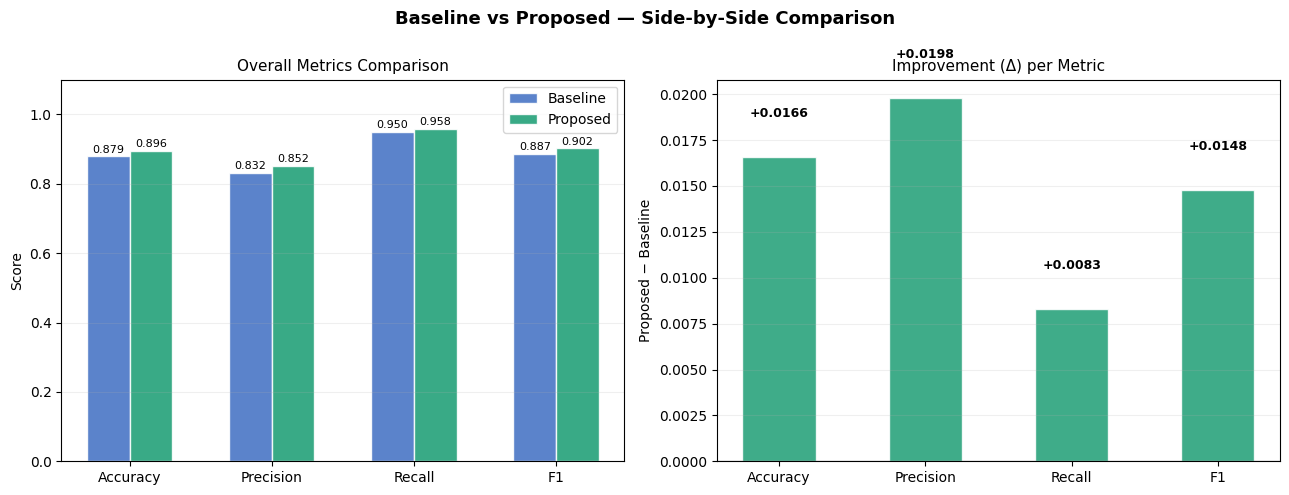

Saved → ./results/comparison_baseline_vs_proposed.png


In [ ]:
# Comparison Table — Baseline vs Proposed
import json, os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load saved metric files
results = {}
for label, fname in [("Baseline", "baseline_metrics.json"), ("Proposed", "proposed_metrics.json")]:
    path = f"./results/{fname}"
    if os.path.exists(path):
        with open(path) as f:
            results[label] = json.load(f)
    else:
        print(f"WARNING: {path} not found — run the respective notebook first.")

if len(results) < 2:
    print("Run both notebooks completely before comparing.")
else:
    # ── Text table ──────────────────────────────────────────────────────
    metrics = ["accuracy", "precision", "recall", "f1"]
    print("=" * 60)
    print("Baseline vs Proposed — Test Set Comparison")
    print("=" * 60)
    print(f"  {'Metric':<14} {'Baseline':>10} {'Proposed':>10} {'Delta':>10} {'Better':>8}")
    print(f"  {'-'*54}")
    for m in metrics:
        b = results["Baseline"][m]
        p = results["Proposed"][m]
        d = p - b
        better = "Proposed ✓" if d > 0 else ("Baseline" if d < 0 else "Tied")
        print(f"  {m.capitalize():<14} {b:>10.4f} {p:>10.4f} {d:>+10.4f} {better:>10}")

    print()
    print("  Per-class F1:")
    for cls in ["genuine", "deceptive"]:
        b = results["Baseline"]["per_class"][cls]["f1"]
        p = results["Proposed"]["per_class"][cls]["f1"]
        print(f"    {cls.capitalize():<12}  Baseline={b:.4f}  Proposed={p:.4f}  Delta={p-b:+.4f}")

    # ── Visual comparison ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Baseline vs Proposed — Side-by-Side Comparison", fontsize=13, fontweight="bold")

    # Panel 1: Grouped bar — all 4 metrics
    x, w = np.arange(len(metrics)), 0.3
    b_vals = [results["Baseline"][m] for m in metrics]
    p_vals = [results["Proposed"][m] for m in metrics]

    bars_b = axes[0].bar(x - w/2, b_vals, w, label="Baseline", color="#4472C4", alpha=0.88, edgecolor="white")
    bars_p = axes[0].bar(x + w/2, p_vals, w, label="Proposed", color="#1D9E75", alpha=0.88, edgecolor="white")
    for bars in [bars_b, bars_p]:
        for bar in bars:
            h = bar.get_height()
            axes[0].text(bar.get_x()+bar.get_width()/2, h+0.005,
                         f"{h:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([m.capitalize() for m in metrics], fontsize=10)
    axes[0].set_ylim(0, 1.1); axes[0].set_ylabel("Score", fontsize=10)
    axes[0].set_title("Overall Metrics Comparison", fontsize=11)
    axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.2, axis="y")

    # Panel 2: Delta bar (improvement per metric)
    deltas = [p_vals[i] - b_vals[i] for i in range(len(metrics))]
    colors = ["#1D9E75" if d >= 0 else "#C00000" for d in deltas]
    bars_d = axes[1].bar([m.capitalize() for m in metrics], deltas,
                          color=colors, alpha=0.85, edgecolor="white", width=0.5)
    axes[1].axhline(0, color="black", linewidth=0.8)
    for bar, val in zip(bars_d, deltas):
        ypos = bar.get_height() + 0.002 if val >= 0 else bar.get_height() - 0.006
        axes[1].text(bar.get_x()+bar.get_width()/2, ypos,
                     f"{val:+.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[1].set_ylabel("Proposed − Baseline", fontsize=10)
    axes[1].set_title("Improvement (Δ) per Metric", fontsize=11)
    axes[1].grid(True, alpha=0.2, axis="y")

    plt.tight_layout()
    plt.savefig("./results/comparison_baseline_vs_proposed.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → ./results/comparison_baseline_vs_proposed.png")

In [25]:
# STEP 22: Save best model and tokenizer
import os

save_path = "./proposed_model_final"
os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to: {save_path}")
print(f"Files: {os.listdir(save_path)}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.11it/s]

Model saved to: ./proposed_model_final
Files: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


In [27]:
model.save_pretrained("./roberta_fake_review_model")
tokenizer.save_pretrained("./roberta_fake_review_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.43it/s]


('./roberta_fake_review_model\\tokenizer_config.json',
 './roberta_fake_review_model\\tokenizer.json')